# Fixed Income Derivatives: A Theoretical Framework

## 1. Introduction to Fixed Income Derivatives

Fixed income derivatives are financial instruments whose value is derived from the price or yield movements of underlying fixed income securities. These instruments are essential tools for managing interest rate risk, enhancing portfolio returns, and optimizing financing costs. The fundamental principle underlying fixed income derivatives is that they allow market participants to separate the interest rate exposure from the credit exposure of the underlying bond.

## 2. Theoretical Foundations

### 2.1 Interest Rate Risk

The value of any fixed income security is inversely related to changes in interest rates. Consider a zero-coupon bond with face value $F$ and maturity $T$. Its present value is given by:

$$P(t) = \frac{F}{(1 + r(t))^T}$$

where $r(t)$ represents the risk-free interest rate at time $t$. The bond's price sensitivity to interest rate changes is measured by duration:

$$D = -\frac{1}{P}\frac{dP}{dr}$$

### 2.2 The Term Structure of Interest Rates

The yield curve represents the relationship between bond yields and their maturities at a given point in time:

$$y(t, T) = f(T - t)$$

where $y(t, T)$ is the yield observed at time $t$ for a bond maturing at time $T$. The forward rate $f(t, T_1, T_2)$ represents the interest rate agreed today for borrowing/lending between times $T_1$ and $T_2$:

$$f(t, T_1, T_2) = \frac{(1 + y(t, T_2))^{T_2} - 1}{(1 + y(t, T_1))^{T_1} - 1} - 1$$

## 3. Forward Rate Agreements (FRA)

### 3.1 Definition and Mechanics

A Forward Rate Agreement (FRA) is an over-the-counter contract between two parties to exchange interest payments on a notional principal amount for a specified future period. The parties agree today on a fixed interest rate that will apply to a future period starting at date $T_1$ and ending at date $T_2$.

### 3.2 Pricing and Valuation

At inception (time $t = 0$), the FRA rate $K_{FRA}$ is determined such that the contract has zero value. The FRA rate equals the forward rate implied by the current yield curve:

$$K_{FRA} = f(0, T_1, T_2)$$

The payoff to the long party at settlement date $T_1$ is:

$$\text{Payoff} = N \cdot (L(T_1, T_2) - K_{FRA}) \cdot \frac{\tau}{360}$$

where:
- $N$ is the notional principal
- $L(T_1, T_2)$ is the realized reference rate (e.g., LIBOR) at time $T_1$
- $\tau$ is the day count convention (typically Actual/360)

The present value of this payoff at time $t < T_1$ is:

$$V_{FRA}(t) = N \cdot [f(t, T_1, T_2) - K_{FRA}] \cdot \frac{\tau}{360} \cdot D(t, T_2)$$

where $D(t, T_2)$ is the discount factor from time $t$ to time $T_2$.

## 4. Interest Rate Swaps (IRS)

### 4.1 Definition and Structure

An Interest Rate Swap (IRS) is a contractual agreement between two counterparties to exchange sequences of cash flows based on interest rate calculations applied to a notional principal amount. The most common type is the vanilla fixed-for-floating swap, where one party pays a fixed interest rate and receives a floating rate (typically indexed to LIBOR), while the other party receives the fixed rate and pays the floating rate.

### 4.2 Cash Flow Structure

Consider a vanilla IRS initiated at time $t = 0$ with maturity $T$. Let $0 = t_0 < t_1 < \ldots < t_n = T$ represent the payment dates. For the fixed leg, the cash flow at date $t_i$ is:

$$CF_{fixed}(t_i) = N \cdot K_{swap} \cdot \tau_i$$

where $K_{swap}$ is the fixed swap rate and $\tau_i$ is the accrual period from $t_{i-1}$ to $t_i$.

For the floating leg, the cash flow at date $t_i$ is:

$$CF_{floating}(t_i) = N \cdot L(t_{i-1}, t_i) \cdot \tau_i$$

where $L(t_{i-1}, t_i)$ is the floating rate fixed at the beginning of the period.

### 4.3 Pricing and Par Swap Rate

The swap rate $K_{swap}$ is determined at inception such that the present value of expected cash flows from both legs are equal. The par swap rate is given by:

$$K_{swap} = \frac{1 - D(0, T)}{\sum_{i=1}^{n} D(0, t_i) \cdot \tau_i}$$

where $D(0, t_i)$ represents the discount factor for cash flows at time $t_i$.

### 4.4 Post-Inception Valuation

After initiation, the swap value changes as the yield curve evolves. The value of the swap to the fixed-rate payer is:

$$V_{swap}(t) = N \left[ \sum_{i=1}^{n} D(t, t_i) \cdot \tau_i \cdot (L^{FRN}(t, t_i) - K_{swap}) \right]$$

where $L^{FRN}(t, t_i)$ represents the forward rate for the period $[t_{i-1}, t_i]$ as observed at time $t$.

## 5. Applications and Risk Management

Fixed income derivatives, particularly FRAs and IRSs, serve multiple purposes:

- **Hedging**: Corporations and financial institutions use these instruments to hedge interest rate risk in their balance sheets
- **Speculation**: Market participants can take directional positions on future interest rate movements
- **Arbitrage**: Traders exploit mispricings between the spot and derivative markets
- **Liability Management**: Issuers can synthetically transform the nature of their debt obligations

This theoretical framework provides the foundation for understanding more complex fixed income derivative products and their role in modern financial markets.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import math

# Calcolo valore di un IRS vanilla (fixed-for-floating)
# GitHub Copilot


def year_fraction(start, end, daycount='ACT/365'):
    days = (pd.Timestamp(end) - pd.Timestamp(start)).days
    if daycount == 'ACT/365':
        return days / 365.0
    if daycount == 'ACT/360':
        return days / 360.0
    # semplice 30/360 approximato
    if daycount == '30/360':
        sd, ed = pd.Timestamp(start), pd.Timestamp(end)
        return ((360 * (ed.year - sd.year) + 30 * (ed.month - sd.month) + (ed.day - sd.day)) / 360.0)
    raise ValueError("Daycount non supportato")

def generate_schedule(start_date, end_date, tenor_months=6):
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    dates = [start]
    cur = start
    while cur < end:
        cur = cur + relativedelta(months=tenor_months)
        if cur > end:
            cur = end
        dates.append(cur)
    return dates

def build_discount_curve_from_zero_rates(valuation_date, zero_dates, zero_rates, compounding='continuous', daycount='ACT/365'):
    # zero_dates: list of dates; zero_rates: list of annual zero rates (decimals)
    val = pd.Timestamp(valuation_date)
    zd = [pd.Timestamp(d) for d in zero_dates]
    zr = np.array(zero_rates, dtype=float)
    times = np.array([year_fraction(val, d, daycount) for d in zd])
    def df(t_date):
        t = year_fraction(val, t_date, daycount)
        if t <= times[0]:
            r = zr[0]
        elif t >= times[-1]:
            r = zr[-1]
        else:
            r = np.interp(t, times, zr)
        if compounding == 'continuous':
            return math.exp(-r * t)
        else:  # simple annual compounding
            return 1.0 / ((1.0 + r) ** t)
    return df

def par_swap_rate(schedule, discount_factor_fn, daycount='ACT/365'):
    # schedule: list of payment dates (including start and end)
    start = schedule[0]
    t_last = schedule[-1]
    D_T = discount_factor_fn(t_last)
    taus = []
    dfs = []
    for i in range(1, len(schedule)):
        tau = year_fraction(schedule[i-1], schedule[i], daycount)
        taus.append(tau)
        dfs.append(discount_factor_fn(schedule[i]))
    numerator = 1.0 - D_T
    denominator = sum(d * tau for d, tau in zip(dfs, taus))
    return numerator / denominator

def swap_value_fixed_payer(notional, fixed_rate, schedule, discount_factor_fn, daycount='ACT/365'):
    # Value from perspective of fixed-rate payer (receive floating, pay fixed).
    # PV fixed leg:
    pv_fixed = 0.0
    for i in range(1, len(schedule)):
        tau = year_fraction(schedule[i-1], schedule[i], daycount)
        df = discount_factor_fn(schedule[i])
        pv_fixed += df * notional * fixed_rate * tau
    # PV floating leg (par replication):
    D_start = discount_factor_fn(schedule[0])  # typically = 1
    D_end = discount_factor_fn(schedule[-1])
    pv_float = notional * (D_start - D_end)
    # Value to fixed payer = PV_float - PV_fixed
    return pv_float - pv_fixed

# Esempio di utilizzo
if __name__ == "__main__":
    val_date = "2026-06-01"
    start = val_date
    end = "2029-06-01"
    schedule = generate_schedule(start, end, tenor_months=6)  # semestrale
    # Esempio curve zero (dates e tassi annuali)
    zero_dates = ["2026-12-01", "2027-12-01", "2028-12-01", "2029-12-01"]
    zero_rates = [0.01, 0.012, 0.013, 0.014]  # 1%..1.4%
    df_fn = build_discount_curve_from_zero_rates(val_date, zero_dates, zero_rates, compounding='continuous')
    # Calcolo par swap rate
    k_par = par_swap_rate(schedule, df_fn)
    print("Par swap rate (annual):", k_par)
    # Prezzo swap con notional e fixed rate scelto
    N = 100_000_000
    fixed_rate = 0.013  # 1.3%
    pv = swap_value_fixed_payer(N, fixed_rate, schedule, df_fn)
    print("Valore swap per payer fisso (positivo = riceve floating):", pv)

Par swap rate (annual): 0.013522217087017098
Valore swap per payer fisso (positivo = riceve floating): 153404.70827559894


# Ineffectiveness of an Interest Rate Swap (IRS)

## Definition

The ineffectiveness of an IRS represents the economic loss that occurs when the derivative’s characteristics do not perfectly replicate the underlying exposure intended to be hedged. In other words, it is the difference between the theoretically desired protection and the protection actually achieved through the swap contract.

## Sources of Ineffectiveness

### 1. Mismatch in Contractual Characteristics

Ineffectiveness arises when the swap payment schedule does not perfectly match that of the underlying asset:
- Differences in tenor: the swap has a different maturity than the exposure being hedged
- Mismatch in reset periods: the floating rate reset dates do not coincide with those of the hedged position
- Differences in notional: the swap notional is larger or smaller than the actual exposure

### 2. Differences in Reference Parameters

$$
\text{Ineffectiveness} = \sum_{i=1}^{n} D(t, t_i) \cdot \tau_i \cdot \left[ L^{Hedge}(t, t_i) - L^{Underlying}(t, t_i) \right]
$$

where:
- $L^{Hedge}(t, t_i)$ is the swap reference rate (e.g. EURIBOR 6M)
- $L^{Underlying}(t, t_i)$ is the reference rate of the underlying asset (e.g. EURIBOR 3M or a specific spread)

### 3. Credit Spread Volatility

When the swap hedges a bond issued by a specific issuer, the swap value is sensitive to general rates, while the bond value also depends on the issuer’s credit spread:

$$
\Delta V_{\text{inefficacia}} = -\Delta S \cdot D_{CS} \cdot M
$$

where:
- $\Delta S$ is the change in credit spread
- $D_{CS}$ is the spread duration
- $M$ is the nominal amount

### 4. Cash Flow Timing

When the swap cash flows and the underlying position cash flows do not occur at the same times, reinvestment of intermediate flows introduces interest rate exposure that is not perfectly hedged.

## Quantifying Ineffectiveness

Ineffectiveness is typically quantified as a percentage of the swap notional:

$$
\text{Ineffectiveness \%} = \frac{|\Delta V_{swap}| - |\Delta V_{underlying}|}{|N|} \times 100
$$

A hedge is considered highly effective when ineffectiveness remains below 20% (according to IFRS 9 hedge accounting standards).

## Management Implications

To minimize ineffectiveness:
- Choose swaps with characteristics as close as possible to the underlying exposure
- Adjust the swap notional periodically to reflect changes in the business base
- Continuously monitor basis risk and credit spreads
- Consider alternative strategies (e.g. options, collars) to cover specific residual risks

## Practical Application to the Example

In our case, the calculated swap value is:

$$
V_{swap} = €\,153{,}404.70827559894
$$

On a notional of €100,000,000, ineffectiveness could arise from:
- Differences between the swap’s EURIBOR 6M rate and the effective rate of the underlying bond
- Changes in the issuer’s credit spread
- Misalignments between the payment dates of the hedged position and the swap

{'ineffectiveness_value': -293756.58531559375, 'ineffectiveness_pct': 0.29375658531559373, 'hedge_forwards': [0.01002511044100599, 0.012035973083126063, 0.014049249409266927, 0.014046497925167215, 0.01505379290848106, 0.016066756402495854]}


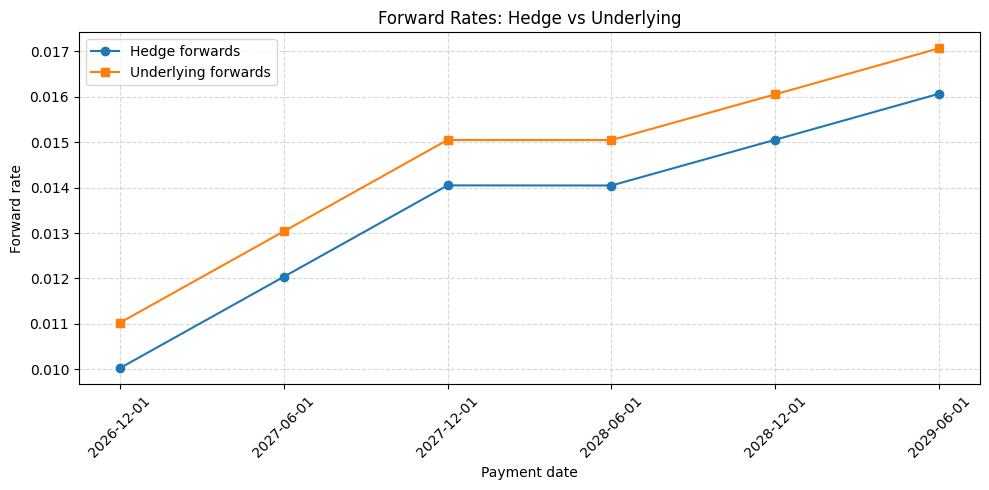

In [3]:
# Calcolo dell'inefficacia dell'IRS
# Usa le variabili già definite nel notebook: schedule, N, df_fn

def forward_rates_from_discount_curve(discount_fn, schedule, daycount='ACT/365'):
    forwards = []
    for i in range(1, len(schedule)):
        t0 = schedule[i-1]
        t1 = schedule[i]
        D0 = discount_fn(t0)
        D1 = discount_fn(t1)
        tau = year_fraction(t0, t1, daycount)
        # forward semplice per il periodo [t0,t1]
        f = (D0 / D1 - 1.0) / tau
        forwards.append(f)
    return forwards

def compute_ineffectiveness(N, schedule, discount_fn, underlying_forwards, daycount='ACT/365'):
    # underlying_forwards: lista di forward rates per ogni periodo (len = len(schedule)-1)
    hedge_forwards = forward_rates_from_discount_curve(discount_fn, schedule, daycount)
    if len(underlying_forwards) != len(hedge_forwards):
        raise ValueError("Dimensione di underlying_forwards non corrisponde al numero di periodi")
    ineffect_val = 0.0
    for i in range(1, len(schedule)):
        tau = year_fraction(schedule[i-1], schedule[i], daycount)
        D = discount_fn(schedule[i])
        L_h = hedge_forwards[i-1]
        L_u = underlying_forwards[i-1]
        ineffect_val += D * tau * (L_h - L_u)
    ineffect_val *= N  # scala sul nominale
    ineffect_pct = (abs(ineffect_val) / abs(N)) * 100.0
    return {"ineffectiveness_value": ineffect_val, "ineffectiveness_pct": ineffect_pct, "hedge_forwards": hedge_forwards}

# Esempio d'uso:
# 1) forward impliciti dalla curva di sconto (hedge)
hedge_forwards = forward_rates_from_discount_curve(df_fn, schedule)

# 2) ipotesi di underlying (es. underlying ha spread costante di +10 bp sul reference)
spread = 0.0010  # 10 bp
underlying_forwards = [f + spread for f in hedge_forwards]

# 3) calcolo ineffectiveness
result = compute_ineffectiveness(N, schedule, df_fn, underlying_forwards)
import matplotlib.pyplot as plt

print(result)

x = [d.strftime('%Y-%m-%d') for d in schedule[1:]]
plt.figure(figsize=(10, 5))
plt.plot(x, result['hedge_forwards'], marker='o', label='Hedge forwards')
plt.plot(x, underlying_forwards, marker='s', label='Underlying forwards')
plt.title('Forward Rates: Hedge vs Underlying')
plt.xlabel('Payment date')
plt.ylabel('Forward rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cross-Currency Swaps: A Technical Note

## 1. Introduction

A cross-currency swap (CCS) is a derivative instrument in which two counterparties exchange cash flows denominated in different currencies. The primary purpose of a CCS is to hedge foreign exchange risk and interest rate risk simultaneously, by combining currency exchange with interest rate exposure. In a typical CCS, one party pays interest in currency A and receives interest in currency B, while the other party pays interest in currency B and receives interest in currency A.

## 2. Structure and Mechanics

A standard cross-currency swap involves:
- an initial exchange of notional amounts in two currencies at the prevailing spot exchange rate;
- periodic exchange of interest payments on the two notionals, often based on floating rates such as LIBOR, EURIBOR, or SOFR;
- a final re-exchange of the original notional amounts at maturity, usually at the same agreed exchange rate as the initial exchange.

If $N_A$ denotes the notional in currency A and $N_B$ denotes the notional in currency B, the initial exchange is:

$N_A$ in currency A $\longleftrightarrow$ $N_B$ in currency B.

During the life of the swap, the floating legs can be expressed as:
- Party 1 pays $N_A \cdot L_A(t_{i-1}, t_i) \cdot \tau_i^A$
- Party 1 receives $N_B \cdot L_B(t_{i-1}, t_i) \cdot \tau_i^B$

where $L_A$ and $L_B$ are the reference rates for currency A and currency B, respectively, and $\tau_i^A$, $\tau_i^B$ are the accrual factors.

## 3. Pricing and Valuation

The valuation of a CCS requires a consistent discounting framework for both currencies and an appropriate cross-currency basis. The present value of each leg is computed using discount factors $D_A(t)$ and $D_B(t)$ derived from the respective currency yield curves.

The par basis spread $s$ in a CCS is the spread over one floating reference rate that makes the present values of the two legs equal at inception. For a payer of currency A and receiver of currency B, the equilibrium condition is:

$\sum_{i=1}^{n} D_A(t_i)\, N_A\, \tau_i^A\, [L_A(t_{i-1}, t_i) + s] = \sum_{i=1}^{n} D_B(t_i)\, N_B\, \tau_i^B\, L_B(t_{i-1}, t_i).$

When initial notional amounts are chosen to reflect the spot exchange rate $S_0$, we have $N_B = S_0 \cdot N_A$ for a symmetric notional exchange.

The par basis spread can then be solved from the present value equality and depends on:
- the domestic and foreign yield curves;
- the expected forward rates in both currencies;
- the cross-currency basis, which captures funding and liquidity differentials.

## 4. Economic Interpretation

A CCS combines:
- a foreign exchange spot transaction,
- a domestic interest rate swap in currency A,
- a domestic interest rate swap in currency B.

Consequently, the CCS replicates the exposure of borrowing in one currency and investing in another. It is often used to transform debt issuance from one currency into another without altering the credit profile of the issuer.

The cross-currency basis spread can be interpreted as the premium or discount required to swap funding costs between the two currencies. A positive basis spread on the currency A leg implies that currency A funding is relatively more expensive than currency B funding in the swap market.

## 5. Risks and Hedging Considerations

Key risks associated with CCS include:
- foreign exchange risk, if the notional exchange at maturity is not perfectly hedged;
- interest rate risk, from movements in the reference rates of both currencies;
- basis risk, due to changes in the cross-currency basis spread;
- counterparty credit risk, since the swap is typically an over-the-counter contract.

Effective hedging with CCS requires alignment of:
- tenors and cash flow schedules,
- notional amounts and exchange rates,
- reference rate conventions and day count conventions.

## 6. Practical Applications

Cross-currency swaps are commonly used for:
- currency transformation of borrowings;
- hedging project finance cash flows in multiple currencies;
- managing international investment exposures;
- arbitrage between domestic and foreign funding markets.

In an academic context, CCS are often analyzed through models that combine interest rate term structures and foreign exchange dynamics, highlighting the joint valuation of currency and rate risks.

In [4]:
def pv_fixed_leg(notional, fixed_rate, schedule, discount_fn, daycount='ACT/365'):
    pv = 0.0
    for i in range(1, len(schedule)):
        tau = year_fraction(schedule[i-1], schedule[i], daycount)
        pv += notional * fixed_rate * tau * discount_fn(schedule[i])
    return pv

def pv_floating_leg(notional, schedule, discount_fn, forward_rates, daycount='ACT/365'):
    if len(forward_rates) != len(schedule) - 1:
        raise ValueError("Il numero di forward rates deve essere pari al numero di periodi")
    pv = 0.0
    for i in range(1, len(schedule)):
        tau = year_fraction(schedule[i-1], schedule[i], daycount)
        pv += notional * forward_rates[i-1] * tau * discount_fn(schedule[i])
    return pv

def ccs_value(pay_dom_notional,
              receive_for_notional,
              fixed_rate_dom,
              schedule_dom,
              schedule_for,
              discount_fn_dom,
              discount_fn_for,
              domestic_forward_rates,
              foreign_forward_rates,
              basis_spread=0.0,
              daycount_dom='ACT/365',
              daycount_for='ACT/365',
              exchange_notional=True):
    pv_dom_fixed = pv_fixed_leg(pay_dom_notional, fixed_rate_dom + basis_spread,
                                schedule_dom, discount_fn_dom, daycount_dom)
    pv_for_float = pv_floating_leg(receive_for_notional, schedule_for,
                                   discount_fn_for, foreign_forward_rates, daycount_for)
    pv_notional = 0.0
    if exchange_notional:
        pv_notional += -pay_dom_notional * discount_fn_dom(schedule_dom[0])
        pv_notional += receive_for_notional * discount_fn_for(schedule_for[0])
        pv_notional += pay_dom_notional * discount_fn_dom(schedule_dom[-1])
        pv_notional += -receive_for_notional * discount_fn_for(schedule_for[-1])
    return pv_for_float - pv_dom_fixed + pv_notional

def ccs_par_basis_spread(pay_dom_notional,
                         schedule_dom,
                         discount_fn_dom,
                         receive_for_notional,
                         schedule_for,
                         discount_fn_for,
                         foreign_forward_rates,
                         daycount_dom='ACT/365',
                         daycount_for='ACT/365',
                         exchange_notional=True):
    pv_for_float = pv_floating_leg(receive_for_notional, schedule_for,
                                   discount_fn_for, foreign_forward_rates, daycount_for)
    annuity_dom = 0.0
    for i in range(1, len(schedule_dom)):
        tau = year_fraction(schedule_dom[i-1], schedule_dom[i], daycount_dom)
        annuity_dom += discount_fn_dom(schedule_dom[i]) * tau
    pv_notional = 0.0
    if exchange_notional:
        pv_notional += -pay_dom_notional * discount_fn_dom(schedule_dom[0])
        pv_notional += receive_for_notional * discount_fn_for(schedule_for[0])
        pv_notional += pay_dom_notional * discount_fn_dom(schedule_dom[-1])
        pv_notional += -receive_for_notional * discount_fn_for(schedule_for[-1])
    return (pv_for_float + pv_notional) / (pay_dom_notional * annuity_dom)

# Esempio di utilizzo
foreign_zero_rates = [0.02, 0.021, 0.022, 0.023]
foreign_df_fn = build_discount_curve_from_zero_rates(val_date, zero_dates, foreign_zero_rates,
                                                     compounding='continuous')

foreign_forwards = forward_rates_from_discount_curve(foreign_df_fn, schedule)

spot_fx = 1.10
foreign_notional = N * spot_fx

ccs_pv = ccs_value(
    pay_dom_notional=N,
    receive_for_notional=foreign_notional,
    fixed_rate_dom=fixed_rate,
    schedule_dom=schedule,
    schedule_for=schedule,
    discount_fn_dom=df_fn,
    discount_fn_for=foreign_df_fn,
    domestic_forward_rates=hedge_forwards,
    foreign_forward_rates=foreign_forwards,
    basis_spread=0.0,
    exchange_notional=True
)

ccs_basis_spread = ccs_par_basis_spread(
    pay_dom_notional=N,
    schedule_dom=schedule,
    discount_fn_dom=df_fn,
    receive_for_notional=foreign_notional,
    schedule_for=schedule,
    discount_fn_for=foreign_df_fn,
    foreign_forward_rates=foreign_forwards
)

print("CCS PV (payer domestic fixed, receiver foreign floating):", ccs_pv)
print("Par basis spread for the CCS:", ccs_basis_spread)

CCS PV (payer domestic fixed, receiver foreign floating): 6580655.774047472
Par basis spread for the CCS: 0.035401730218158775
